# Quadratic Discriminant Analysis (QDA)

## 1. Problem Setup

We have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}, \quad x_i \in \mathbb{R}^D, \ y_i \in \{0,1,\dots,K-1\}
$$

where the goal is to predict class labels $y$ from features $x$.

---

## 2. QDA Assumptions

QDA assumes:

1. Each class $k$ follows a **multivariate Gaussian distribution**:

$$
x \mid y=k \sim \mathcal{N}(\mu_k, \Sigma_k)
$$

2. Covariance matrices are **class-specific**:

$$
\Sigma_0 \neq \Sigma_1 \neq \dots \neq \Sigma_{K-1}
$$

3. Class priors are estimated from data:

$$
\pi_k = P(y=k)
$$

> Unlike LDA, QDA allows each class to have its own covariance, enabling **non-linear boundaries**.

---

## 3. Class Means and Covariances

For each class $k$:

- Mean vector:

$$
\mu_k = \frac{1}{N_k} \sum_{i:y_i=k} x_i
$$

- Covariance matrix:

$$
\Sigma_k = \frac{1}{N_k} \sum_{i:y_i=k} (x_i - \mu_k)(x_i - \mu_k)^T + \lambda I
$$

where $\lambda$ is a small regularization term.

---

## 4. QDA Discriminant Function

The discriminant for class \(k\) is:

$$
\delta_k(x) = -\frac{1}{2} \ln|\Sigma_k| - \frac{1}{2} (x-\mu_k)^T \Sigma_k^{-1} (x-\mu_k) + \ln \pi_k
$$

Prediction:

$$
\hat{y} = \arg\max_k \delta_k(x)
$$

---

## 5. Decision Boundary

- QDA produces **quadratic boundaries** because covariance matrices differ across classes.  
- If all $\Sigma_k$ are equal, QDA reduces to **LDA** and boundaries become linear.

---


In [1]:
class QDA:
    """
    Quadratic Discriminant Analysis (QDA) classifier.

    Assumes that each class follows a multivariate normal distribution with its own covariance matrix.

    Parameters
    ----------
    reg : float, default=1e-10
        Regularization term added to covariance matrices for numerical stability.

    Attributes
    ----------
    classes : ndarray of shape (num_classes,)
        Unique class labels in the training data.

    num_classes : int
        Number of classes.

    pi_k : ndarray of shape (num_classes,)
        Prior probabilities for each class.

    N_k : ndarray of shape (num_classes,)
        Number of samples in each class.

    mu_k : ndarray of shape (num_classes, D)
        Mean vector for each class.

    sigma_k : ndarray of shape (num_classes, D, D)
        Covariance matrix for each class.
    """
    def __init__(self,reg=1e-10):
        self.reg = reg

        self.classes= None
        self.num_classes = None
        self.pi_k = None
        self.N_k = None
        self.mu_k = None
        self.sigma_k = None

    def fit(self,X,y):
        """
        Fit QDA model to training data.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Training feature matrix.

        y : ndarray of shape (N,)
            Class labels.

        Returns
        -------
        self : object
            Fitted estimator.
        """
        # Identify classes and counts
        self.classes, self.N_k = np.unique(y, return_counts=True)
        N,D = X.shape
        self.num_classes = len(self.classes)
        
        # Compute class priors
        self.pi_k = self.N_k/N

        # Compute class means
        self.mu_k = np.array([X[y==k].mean(axis=0) for k in self.classes])

        # Compute class-specific covariance matrices
        self.sigma_k = np.zeros((self.num_classes,D,D))


        for i, k in enumerate(self.classes):
            X_centered = X[y==k] - self.mu_k[i]
            self.sigma_k [i,:,:] = X_centered.T @ X_centered / self.N_k[i]

        self.sigma_k += self.reg * np.eye(D)
        
        return self

    def predict(self,X):
        """
        Predict class labels for given data.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Feature matrix for prediction.

        Returns
        -------
        y_pred : ndarray of shape (N,)
            Predicted class labels.
        """
        N,D = X.shape
        
        
        delta_k = np.zeros((N, self.num_classes))
        
        # Compute discriminant scores for each class
        for i, k in enumerate(self.classes):
            X_centered = X - self.mu_k[i]
            _ , det = np.linalg.slogdet(self.sigma_k[i])
            delta_k[:,i] =np.log(self.pi_k[i])- 0.5*det - 0.5 * (X_centered * solve(self.sigma_k[i],X_centered.T).T).sum(axis=1)

        # Assign class with maximum discriminant score
        return np.argmax(delta_k,axis=1)
 

## 1. Objective

The goal is to analyze how **Quadratic Discriminant Analysis (QDA)** behaves under:

- Equal class covariance (ideal/simple case)
- Different class covariance (general/realistic case)

We study how the **decision boundary changes** and its impact on classification accuracy.

---

## 2. Dataset 

Generate two synthetic datasets:

### Case 1: Proper Covariance (Equal Covariance)

Both classes share the same covariance matrix:

$$
\Sigma_0 = \Sigma_1 =
\begin{bmatrix}
1 & 0.5 \\
0.5 & 1
\end{bmatrix}
$$

Class means:

$$
\mu_0 = \begin{bmatrix}0 \\ 0\end{bmatrix}, \quad
\mu_1 = \begin{bmatrix}3 \\ 0\end{bmatrix}
$$



### Case 2: Violated Covariance (Different Covariance)

Each class has a different covariance:

$$
\Sigma_0 =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}, \quad
\Sigma_1 =
\begin{bmatrix}
3 & 1.5 \\
1.5 & 1
\end{bmatrix}
$$

This results in:

- Different spread
- Different orientation

---

## 3. Data Generation

Each class is sampled as:

$$
x \mid y=k \sim \mathcal{N}(\mu_k, \Sigma_k)
$$

The dataset is:

$$
X = \begin{bmatrix} X_0 \\ X_1 \end{bmatrix}, \quad
y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}
$$

---

## 4. QDA Model

QDA assumes:

$$
x \mid y=k \sim \mathcal{N}(\mu_k, \Sigma_k)
$$

with **class-specific covariance matrices**.

---

## 5. Decision Function

The discriminant function for class $k$ is:

$$
\delta_k(x) =
\log \pi_k
- \frac{1}{2} \log |\Sigma_k|
- \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
$$

Prediction:

$$
\hat{y} = \arg\max_k \delta_k(x)
$$

---






In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve



# Dataset
def generate_data_qda(N=100, violation=False):
    np.random.seed(42)
    mu0 = np.array([0, 0])
    mu1 = np.array([3, 0])  

    if violation:
        Sigma0 = np.array([[1, 0], [0, 1]])
        Sigma1 = np.array([[3, 1.5], [1.5, 1]])  
    else:
        Sigma0 = np.array([[1, 0.5], [0.5, 1]])
        Sigma1 = Sigma0.copy()

    X0 = np.random.multivariate_normal(mu0, Sigma0, N)
    X1 = np.random.multivariate_normal(mu1, Sigma1, N)

    X = np.vstack([X0, X1])
    y = np.array([0]*N + [1]*N)
    return X, y

datasets = {
    "QDA Proper Covariance": generate_data_qda(violation=False),
    "QDA Violated Covariance": generate_data_qda(violation=True)
}

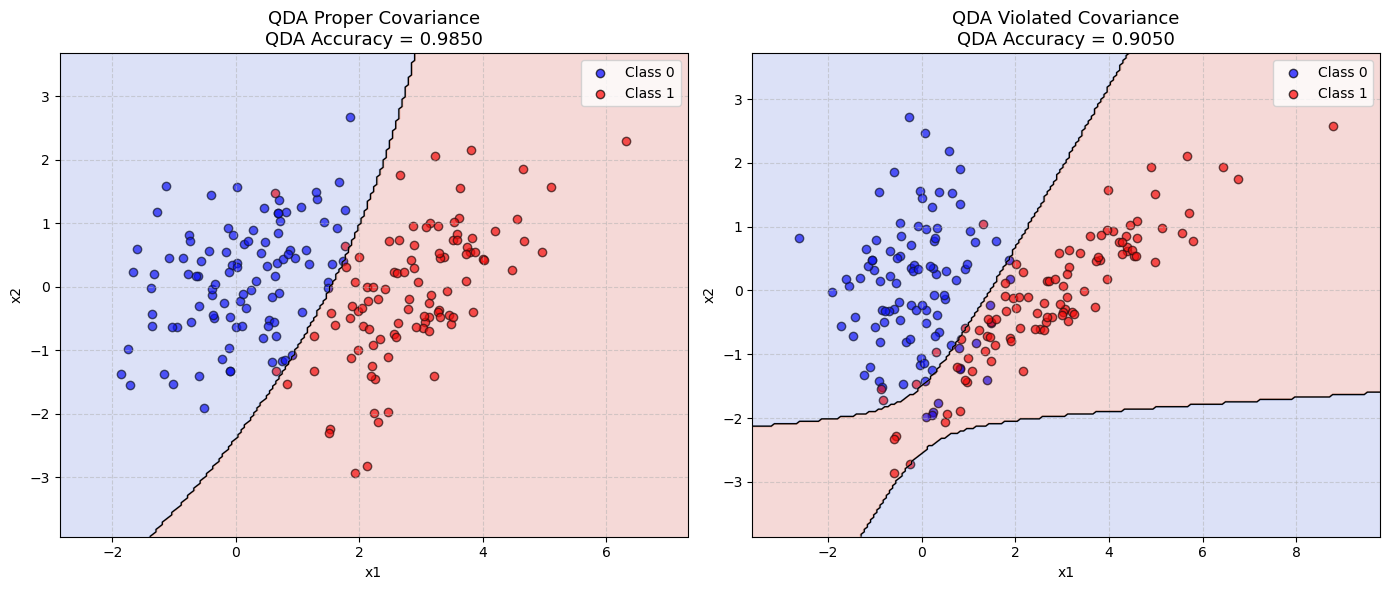

In [3]:
# Plot

plt.figure(figsize=(14,6))

for i, (name, (X, y)) in enumerate(datasets.items()):
    model = QDA()
    model.fit(X, y)
    y_pred = model.predict(X)
    acc = np.mean(y_pred == y)

    ax = plt.subplot(1, 2, i+1)

    # Scatter points
    ax.scatter(X[y==0,0], X[y==0,1], color='blue', edgecolor='k', label='Class 0', alpha=0.7)
    ax.scatter(X[y==1,0], X[y==1,1], color='red', edgecolor='k', label='Class 1', alpha=0.7)

    # QDA Decision boundary
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1)

    ax.set_title(f"{name}\nQDA Accuracy = {acc:.4f}", fontsize=13)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Observations

### Proper Covariance Case

- Covariances are equal:
  
$$
\Sigma_0 = \Sigma_1
$$

- QDA behaves like LDA
- Decision boundary appears approximately **linear**
- High classification accuracy


### Violated Covariance Case

- Covariances differ:

$$
\Sigma_0 \neq \Sigma_1
$$

- QDA produces a **quadratic boundary**
- Captures class-specific spread and orientation
- More flexible than linear models

---

## 7. Important

- QDA adapts to covariance structure automatically:

$$
\text{Equal covariance} \Rightarrow \text{Linear boundary}
$$

$$
\text{Different covariance} \Rightarrow \text{Quadratic boundary}
$$

---

## 8. Conclusion

- QDA is a **generalization of LDA**
- It is more flexible due to class-specific covariance matrices
- It performs especially well when:

  - Classes have different shapes
  - Data is not linearly separable

- However, it requires:
  - More data (to estimate covariance reliably)
  - Regularization for numerical stability



---